# Module Assignment — Exploratory Data Analysis on Hotel Bookings

## Case Study: Hotel Bookings

In this assignment you'll apply everything from this module to a **large, genuinely messy** real-world dataset: **119,390 hotel bookings with 32 columns**.

You will practise the full EDA workflow:

1. **Exploring / diagnosing** the data
2. **Cleaning** — missing values, duplicates, wrong data types, invalid values
3. **Visualizing** with matplotlib
4. **Manipulating** — sorting, filtering, new columns, `groupby`, `pivot_table`, `crosstab`
5. **Drawing conclusions**

**This dataset is deliberately challenging** — it has 4 columns with missing data (one is ~94% empty!), ~32,000 duplicate rows, dates stored as text, and some physically impossible values. Read each prompt carefully and think about *why* a step is needed, not just *how*.

### Instructions

- Write your **full code** in the empty cell below each exercise
- Some exercises ask a question in **markdown** — answer it in a comment or a short written note.
- Work through the notebook **in order**: later sections rely on the cleaned DataFrame from earlier ones.
- Worked answers are in **`Module_Assignment_Hotel_Bookings_Solutions.ipynb`** — try hard before peeking.

### Key columns

| Column | Meaning |
|---|---|
| `hotel` | Resort Hotel or City Hotel |
| `is_canceled` | 1 = booking was cancelled, 0 = not |
| `lead_time` | Days between booking and arrival |
| `arrival_date_month` | Month of arrival (text, e.g. "July") |
| `adults` / `children` / `babies` | Number of guests of each type |
| `meal`, `country`, `market_segment`, `customer_type` | Categorical descriptors |
| `adr` | Average Daily Rate (price per night) |
| `agent` / `company` | IDs of the booking agent / company (lots of missing) |
| `reservation_status_date` | Date of the last status change (text) |

## Import Libraries

**Exercise 0.** Import the required libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

**Exercise 1.** Read `hotel_bookings.csv` into a DataFrame called `df` and display the first 5 rows.

In [5]:
df = pd.read_csv('hotel_bookings.csv') 
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# 1. Exploring / Diagnosing the Data

**Exercise 2.** Report the dataset's **shape** (rows, columns). Then  inspect column names, non-null counts, and dtypes.

In [6]:
print("shape:" , df.shape)
df.info()


shape: (119390, 32)
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal   

**Exercise 3.** Show the summary statistics for the **numeric** columns `. Look at the `adr` column — what is suspicious about its **minimum** value?

In [7]:
df.describe()


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


The “adr” column’s minimum value, -6.88, is unrealistic.

**Exercise 4.** Build a table showing, **for every column**, the number of missing values **and** the percentage missing — sorted from most to least missing. Which columns are the worst?

In [9]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percentage': df.isnull().sum() / len(df) * 100
}).sort_values(by='missing_count', ascending=False)
print(missing)

                                missing_count  missing_percentage
company                                112593           94.306893
agent                                   16340           13.686238
country                                   488            0.408744
children                                    4            0.003350
arrival_date_month                          0            0.000000
arrival_date_week_number                    0            0.000000
hotel                                       0            0.000000
is_canceled                                 0            0.000000
stays_in_weekend_nights                     0            0.000000
arrival_date_day_of_month                   0            0.000000
adults                                      0            0.000000
stays_in_week_nights                        0            0.000000
babies                                      0            0.000000
meal                                        0            0.000000
lead_time 

the worst columns are:
company which is missing ~94% of its values
agent missing ~13% of its  values
country missing less than 1% of its values

**Exercise 5.** For the categorical columns `hotel`, `meal`, `customer_type` and `market_segment`, print the **count of each unique value**.

In [10]:
category_columns = ('hotel', 'meal', 'customer_type', 'market_segment')
for col in category_columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for hotel:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


Value counts for meal:
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


Value counts for customer_type:
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


Value counts for market_segment:
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64




# 2. Cleaning the Data

Work on a copy so the raw data stays intact: start this section with `df_clean = df.copy()`.

**Exercise 6.** Make a copy called `df_clean`. Then handle the missing values:

- `children` → fill missing with `0`
- `country` → fill missing with `"Unknown"`
- `company` and `agent` are mostly empty → **drop both columns**

Confirm there are no missing values left.

In [12]:
df_clean = df.copy()
df_clean['children'] = df_clean['children'].fillna(0)
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean = df_clean.drop(columns=['company','agent'])
print("Remaining missing values:", df_clean.isnull().sum().sum())


Remaining missing values: 0


**Exercise 7.** How many **fully duplicated rows** does `df_clean` contain? Remove them, then confirm the count is now 0 and report the new shape.

In [13]:
print ("Duplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Remaining duplicate rows:", df_clean.duplicated().sum())
print("New Shape after removing duplicates:", df_clean.shape)


Duplicate rows: 32020
Remaining duplicate rows: 0
New Shape after removing duplicates: (87370, 30)


**Exercise 8.** Fix the data types:

- Convert `reservation_status_date` from text to a real **datetime**.
- `children` was a float because of the missing values — now convert it to **int**.

Verify with `.dtypes`.

In [14]:
df_clean['reservation_status_date'] = pd.to_datetime(df_clean['reservation_status_date'])
df_clean['children'] = df_clean['children'].astype(int)
print(df_clean.dtypes[['reservation_status_date', 'children']])


reservation_status_date    datetime64[us]
children                            int64
dtype: object


**Exercise 9.** Remove **invalid values**:

- The `adr` (price) cannot be negative — keep only rows where `adr >= 0`.
- A booking with **zero guests** makes no sense. Create a `total_guests = adults + children + babies` column, then drop rows where `total_guests == 0`.

Report how many rows remain.

In [ ]:
df_clean = df_clean[df_clean['adr'] >= 0]
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']
df_clean = df_clean[df_clean['total_guests'] > 0]
print("Remaining rows:", len(df_clean))

Remaining rows: 87203


# 3. Visualizing the Data 

**Exercise 10.** Plot a **histogram** of `lead_time` (use `bins=50`). Add a title and axis labels. What does the shape tell you about how far in advance people book?

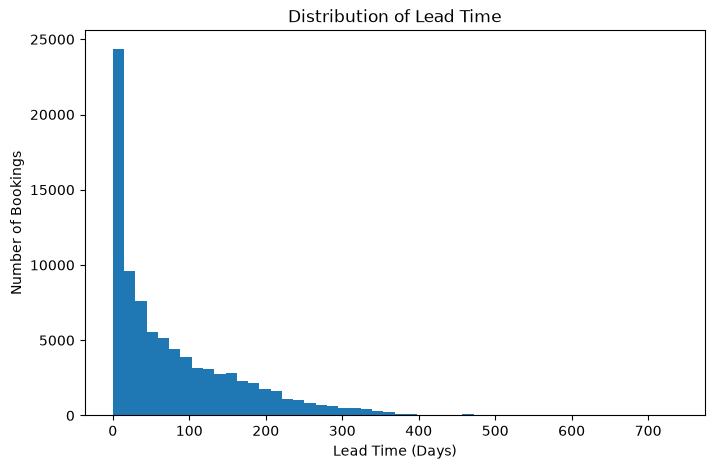

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['lead_time'], bins=50)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Bookings')
plt.show()

# Most people book shortly before their stay, while only a few book far in advance.

**Exercise 11.** Make a **bar chart** of the number of bookings per `hotel` (Resort vs City). Use `value_counts()` and label the chart.

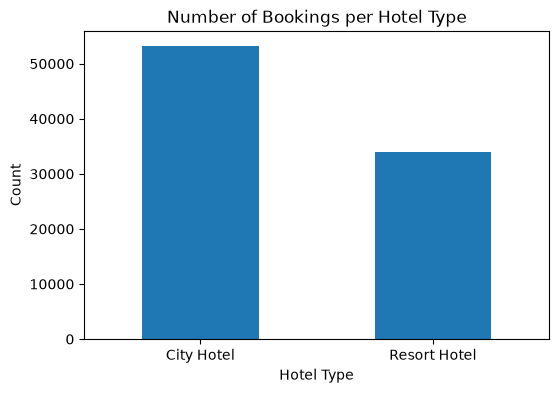

In [20]:
plt.figure(figsize=(6, 4))
df_clean['hotel'].value_counts().plot(kind='bar')
plt.title('Number of Bookings per Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


**Exercise 12.** Draw a **scatter plot** of `lead_time` (x) vs `adr` (y). Use `alpha` and a small marker size `s` so the dense cloud is readable.

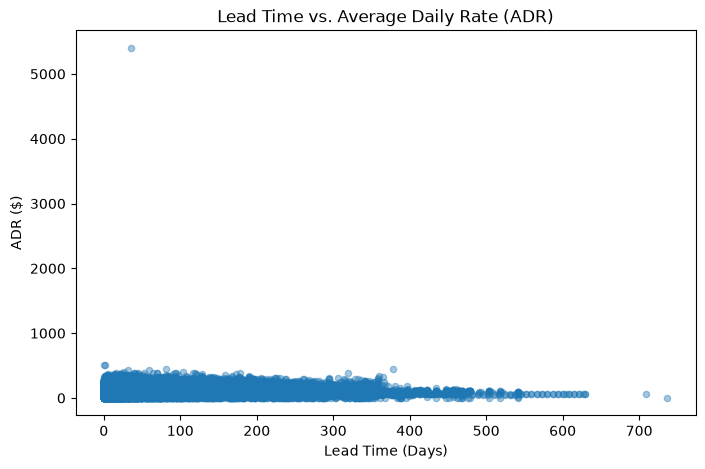

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['lead_time'], df_clean['adr'], alpha=0.4, s=20)
plt.title('Lead Time vs. Average Daily Rate (ADR)')
plt.xlabel('Lead Time (Days)')
plt.ylabel('ADR ($)')
plt.show()


**Exercise 13.** Build a **2×2 grid of subplots** (`figsize=(12, 9)`):

- histogram of `adr`
- histogram of `total_guests`
- bar chart of `customer_type` counts
- bar chart of `is_canceled` counts (0 vs 1)

Give each subplot a title and call `fig.tight_layout()`.

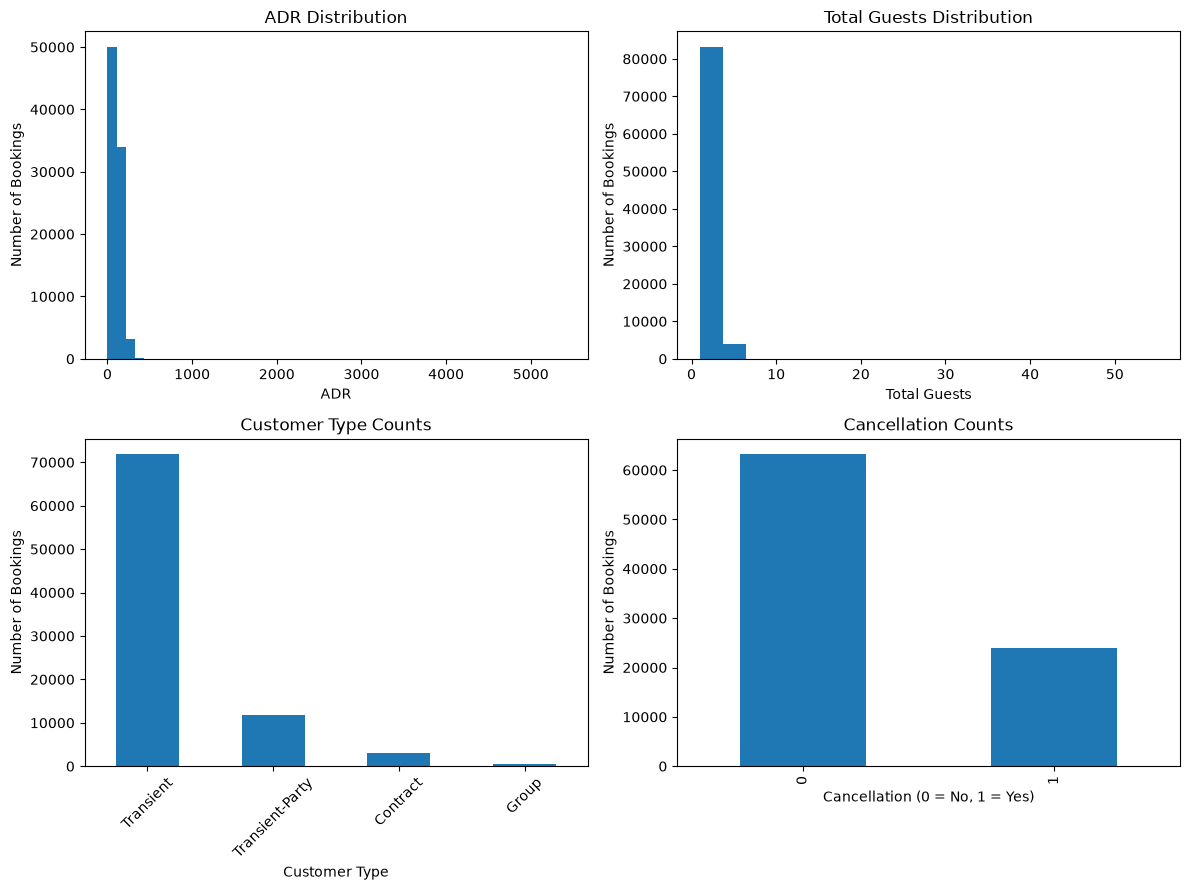

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Histogram of ADR
axes[0, 0].hist(df_clean["adr"], bins=50)
axes[0, 0].set_title("ADR Distribution")
axes[0, 0].set_xlabel("ADR")
axes[0, 0].set_ylabel("Number of Bookings")

# 2. Histogram of Total Guests
axes[0, 1].hist(df_clean["total_guests"], bins=20)
axes[0, 1].set_title("Total Guests Distribution")
axes[0, 1].set_xlabel("Total Guests")
axes[0, 1].set_ylabel("Number of Bookings")

# 3. Bar chart of Customer Type
df_clean["customer_type"].value_counts().plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Customer Type Counts")
axes[1, 0].set_xlabel("Customer Type")
axes[1, 0].set_ylabel("Number of Bookings")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Bar chart of Cancellation
df_clean["is_canceled"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Cancellation Counts")
axes[1, 1].set_xlabel("Cancellation (0 = No, 1 = Yes)")
axes[1, 1].set_ylabel("Number of Bookings")

# Adjust layout
fig.tight_layout()

# Display the figure
plt.show()


**Exercise 14.** Compute the **correlation matrix** of the numeric columns and display it as a **heatmap** using `ax.imshow(..., cmap="coolwarm")`. Add a colorbar and tick labels with the column names.

*Tip: `df_clean.select_dtypes('number').corr()` gives the matrix; use `ax.set_xticks`/`set_yticks` + `set_xticklabels`/`set_yticklabels` for the labels.*

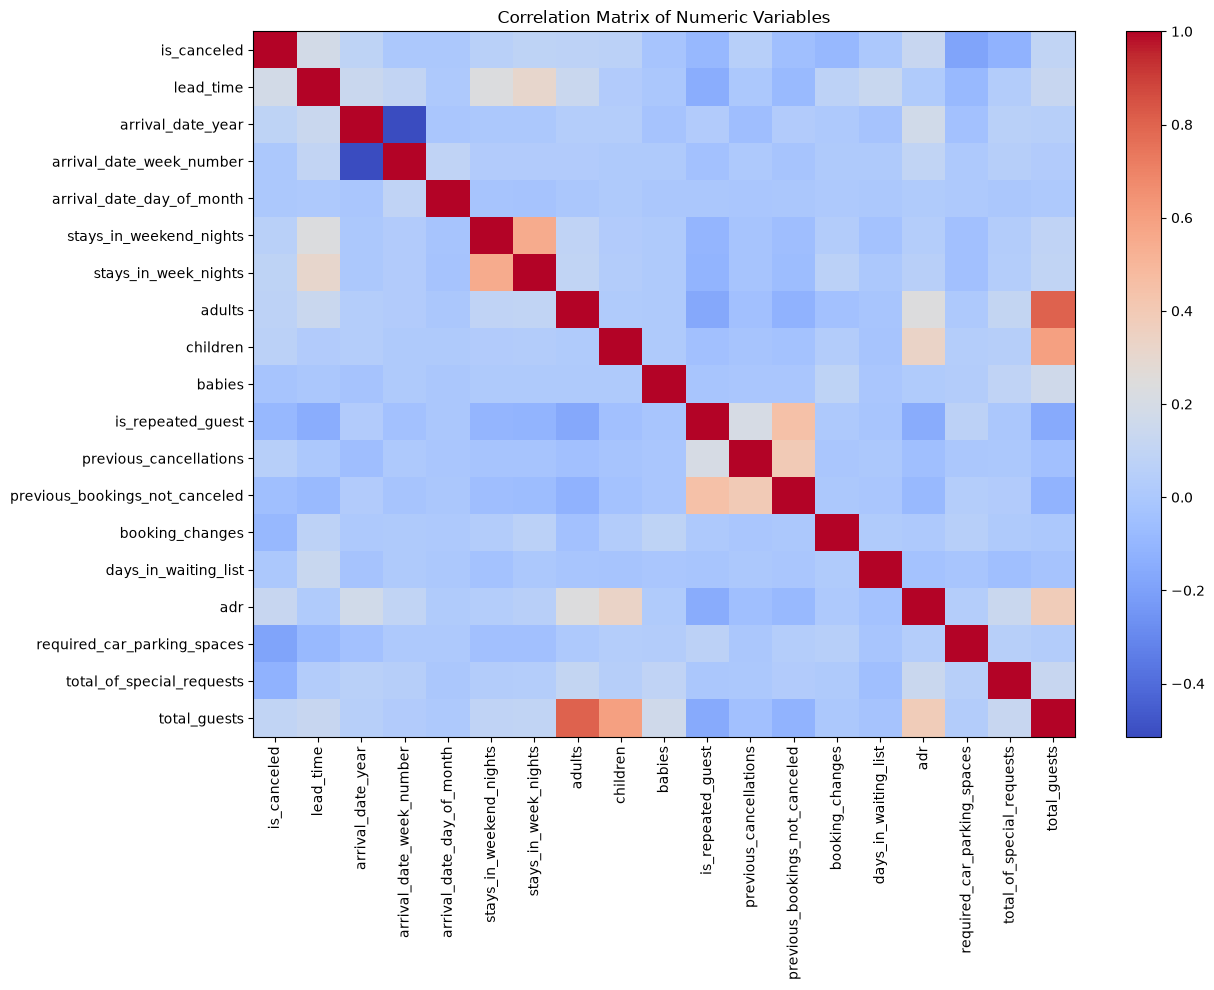

In [32]:
# Your code here
corr = df_clean.select_dtypes("number").corr()

# Create the heatmap
fig, ax = plt.subplots(figsize=(13, 10)) # I choose a larger figure size for better visibility
image = ax.imshow(corr, cmap="coolwarm", aspect="auto")
fig.colorbar(image, ax=ax)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

# Add column names as labels
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Add title
ax.set_title("Correlation Matrix of Numeric Variables")

# Adjust layout
fig.tight_layout()
plt.show()

# 4. Manipulating the Data

**Exercise 15.** **Sort** `df_clean` by `adr` in descending order and show the **top 10** most expensive bookings (columns `hotel`, `arrival_date_month`, `adr`).

In [ ]:
top_10_expensive = df_clean.sort_values('adr', ascending=False)[['hotel', 'arrival_date_month', 'adr']].head(10)
print(top_10_expensive)

               hotel arrival_date_month      adr
48515     City Hotel              March  5400.00
111403    City Hotel                May   510.00
15083   Resort Hotel               July   508.00
103912    City Hotel           December   451.50
13142   Resort Hotel             August   450.00
13391   Resort Hotel             August   437.00
39155   Resort Hotel             August   426.25
39568   Resort Hotel             August   402.00
39118   Resort Hotel               July   397.38
39517   Resort Hotel             August   392.00


**Exercise 16.** Use boolean filtering to select **City Hotel bookings that were cancelled** (`hotel == "City Hotel"` **and** `is_canceled == 1`). How many are there?

In [ ]:
# Your code here
# Create the boolean mask and filter the DataFrame
cancelled_city_hotels = df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 1)]
print("Count of cancelled City Hotel bookings:", len(cancelled_city_hotels))

# They are : 33102 canclled bookings for City Hotel

Count of cancelled City Hotel bookings: 33102


**Exercise 17.** Group by `hotel` and compute the **mean `adr`** and the **cancellation rate** (mean of `is_canceled`) for each hotel. Which hotel cancels more?

In [ ]:
hotel_summary = df_clean.groupby("hotel")[["adr", "is_canceled"]].mean()
print(hotel_summary)

# City Hotel has a higher average ADR and a lower cancellation rate compared to Resort Hotel.


                     adr  is_canceled
hotel                                
City Hotel    111.274295     0.301033
Resort Hotel   99.073648     0.234864


**Exercise 18.** Produce a **grouped summary**: group by **both** `hotel` and `customer_type`, and aggregate `adr` with **mean, median and count** in one call.

In [39]:
grouped_summary = df_clean.groupby(['hotel', 'customer_type'])[['adr']].agg(['mean', 'median', 'count'])
print(grouped_summary)

                                     adr                
                                    mean   median  count
hotel        customer_type                              
City Hotel   Contract         107.854431  103.840   1467
             Group             93.995874   85.000    269
             Transient        114.296209  108.000  44513
             Transient-Party   93.466617   90.000   7011
Resort Hotel Contract          79.693843   72.950   1668
             Group             75.741213   61.600    272
             Transient        103.824229   84.135  27330
             Transient-Party   79.565530   66.000   4673


**Exercise 19.** Build a **`crosstab`** of `hotel` (rows) vs `is_canceled` (columns) to count bookings in each combination.

In [42]:
crosstab_summary = pd.crosstab(
    index=df_clean['hotel'], 
    columns=df_clean['is_canceled'], 
    margins=True,         
    margins_name="Total" 
)
print(crosstab_summary)



is_canceled       0      1  Total
hotel                            
City Hotel    37227  16033  53260
Resort Hotel  25971   7972  33943
Total         63198  24005  87203


**Exercise 20.** Build a **`pivot_table`** with `hotel` as the index, `is_canceled` as the columns, and the **mean `adr`** as the values. Do cancelled bookings have a different average price?

In [43]:
adr_pivot = df.pivot_table(
    index='hotel', 
    columns='is_canceled', 
    values='adr', 
    aggfunc='mean'
)
print(adr_pivot)


is_canceled            0          1
hotel                              
City Hotel    105.745948  104.68792
Resort Hotel   90.788971  105.78701


# 5. Putting It Together

**Exercise 21.** Compute the **cancellation rate per arrival month** and plot it as a bar chart, with the months in **calendar order** (January → December), not alphabetical.

*Tip: group by `arrival_date_month`, take the mean of `is_canceled`, then `.reindex(...)` with a list of month names in order.*

In [ ]:
# Your code here


## 🏆 Challenge Exercises

These are open-ended — combine the skills above and explain what you find in a short comment.

1. **Total nights & revenue:** create `total_nights = stays_in_weekend_nights + stays_in_week_nights`, then estimate revenue as `adr * total_nights`. Which `market_segment` brings the most total estimated revenue? (Remember: cancelled bookings earn nothing — decide how to handle them and justify it.)
2. **Lead time vs cancellation:** bin `lead_time` into buckets (e.g. `pd.cut` at 0, 30, 90, 180, 365, ∞) and show the cancellation rate per bucket. Do bookings made far in advance get cancelled more?
3. **Repeat guests:** compare the cancellation rate of repeated guests (`is_repeated_guest == 1`) vs new guests. Visualize the difference.
4. **Your own question:** pose one question about the data, answer it with code + a plot, and write a one-line conclusion.

In [ ]:
# Your challenge code here


## Conclusion

In a short markdown note below, summarise **3 things you learned** about hotel bookings from this analysis (e.g. which hotel cancels more, when cancellations peak, what drives price).

*Write your conclusions here...*